In [96]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

[np.float64(1.000000000000442), np.float64(437.72867850084367)]
Min and max eigenvalues of A :  None
Result summary -----------------
Optimal centralised alpha =  [ 0.65224744 -0.22137957 -0.32211218  0.41585321 -0.04870779  1.06715439
  0.24875432  0.10640876 -0.38490797 -0.33628325]


/var/folders/lq/fg08dnws0t3188nj5hv6fzs40000gn/T/ipykernel_42418/658518258.py:76: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x,y = pickle.load(f)


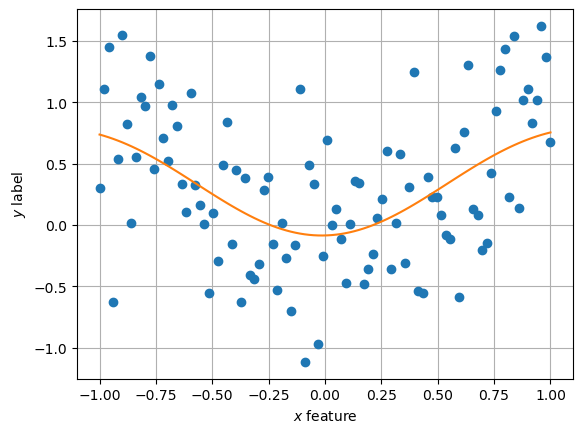

In [97]:
def Cov(x):
    m = len(x)
    Kmm = np.eye(m)
    for ii in range(m):
        for jj in range(ii+1,m):
            Kmm[ii,jj] = np.exp(-(x[ii]-x[jj])**2 )
            Kmm[jj,ii] = Kmm[ii,jj]

    return Kmm

def Cov2(x1,x2):
    m = len(x2)
    n = len(x1)
    Knm = np.zeros([n,m])
    for ii in range(n):
        for jj in range(m):
            Knm[ii, jj] = np.exp(-(x1[ii] - x2[jj]) ** 2 )
    return Knm

def solve(x,y, selection=True):
    n = len(x)

    # you can either select the points among the ones you have:
    if selection:
        sel = [i for i in range(n)]
        ind = np.random.choice(sel, int(np.sqrt(n)), replace=False)
        x2 = [x[i] for i in ind]

    # or take them uniformly distributed
    else:
        x2 = np.linspace(-1, 1, 10)
        ind = []

    M = Cov2(x, x2)
    A = (0.5**2)*Cov(x2) + M.T @ M
    b = M.T @ y

    # here the regularization parameter nu is 1.0
    A = A + 1.*np.eye(int(np.sqrt(n)))

    # it is good to compute the max/min eigenvalues of A for later, but only for small-size matrices
    if n<101:
        ei, EI =np.linalg.eig(A)
        vv = [min(ei), max(ei)]
        print('Min and max eigenvalues of A : ', print(vv))

    alpha = np.linalg.solve(A,b)

    return alpha, ind

def plot_me(x,y, alpha, ind, selection=True):

    plt.plot(x,y,'o')

    xo = np.linspace(-1,1,100)
    if selection:
        x2 = [x[i] for i in ind]
    else:
        x2 = np.linspace(-1, 1, 10)


    yo = Cov2(xo, x2) @ alpha
    plt.plot(xo, yo, '-')
    plt.xlabel(r'$x$ feature')
    plt.ylabel(r'$y$ label')
    plt.grid()

    plt.show()


"""
Main follows
"""

with open('first_database.pkl', 'rb') as f:
   x,y = pickle.load(f)


num_points = 100
alpha, ind = solve(x[:num_points],y[:num_points], selection=True)

print('Result summary -----------------')
print('Optimal centralised alpha = ', alpha)

plot_me(x[:num_points],y[:num_points], alpha, ind, selection=True)

Data generation

In [98]:
n=100
m=10
iter=10000
agentnum=5
agentpoint=20
sigema=0.5
step = 1e-3 * np.ones(iter)
sel = [i for i in range(n)]
ind_centers = ind
x_selected = [x[i] for i in ind_centers]


In [99]:

ind1 = np.random.choice(sel, agentpoint, replace=False)
sel = [i for i in sel if i not in ind1]

ind2 = np.random.choice(sel, agentpoint, replace=False)
sel = [i for i in sel if i not in ind2]

ind3 = np.random.choice(sel, agentpoint, replace=False)
sel = [i for i in sel if i not in ind3]

ind4 = np.random.choice(sel, agentpoint, replace=False)
sel = [i for i in sel if i not in ind4]

ind5 = np.random.choice(sel, agentpoint, replace=False)

ind=np.array([ind1,ind2,ind3,ind4,ind5])

The Gradient function


Let

$$
Y \in \mathbb{R}^{5 \times m}, \quad
g \in \mathbb{R}^{5 \times m}.
$$

The gradient of $F$ satisfies

$$
\nabla F(Y) =
\begin{bmatrix}
\nabla f_1(Y_1) \\
\nabla f_2(Y_2) \\
\vdots \\
\nabla f_5(Y_5)
\end{bmatrix}
\in \mathbb{R}^{5 \times m}.
$$


In [100]:
def gradF(alpha: np.ndarray, agentnum: int = agentnum):
    Grad = np.zeros_like(alpha)
    Kmm = Cov(x_selected)
    ind_arr = np.asarray(ind)
    if ind_arr.ndim == 1:
        ind_arr = ind_arr.reshape(agentnum, -1)
    for i in range(agentnum):
        grad = (sigema ** 2) / 5 * (alpha[i, :] @ Kmm) + (1 / 5) * alpha[i, :]
        for j in ind_arr[i, :]:
            k = Cov2([x[j]], x_selected).reshape(-1)
            grad -= k * (y[j] - k @ alpha[i, :])
        grad = np.clip(grad, -1e3, 1e3)
        Grad[i, :] = grad

    return Grad


Gradient Tracking

In [101]:
W=np.array([[1/5,1/5,1/5,1/5,1/5],[1/5,1/5,1/5,1/5,1/5],[1/5,1/5,1/5,1/5,1/5],[1/5,1/5,1/5,1/5,1/5],[1/5,1/5,1/5,1/5,1/5]])
alpha1 = 0.01 * np.ones((5,m))
g = gradF(alpha1)
mean_alpha = [alpha1.mean(axis=0)]
for i in range(iter):
    alpha_prev = alpha1.copy()
    alpha1 = W @ alpha1 - step[i] * g
    alpha1 = np.clip(alpha1, -1e3, 1e3)
    g = W @ g + gradF(alpha1) - gradF(alpha_prev)
    mean_alpha.append(alpha1.mean(axis=0))


Result


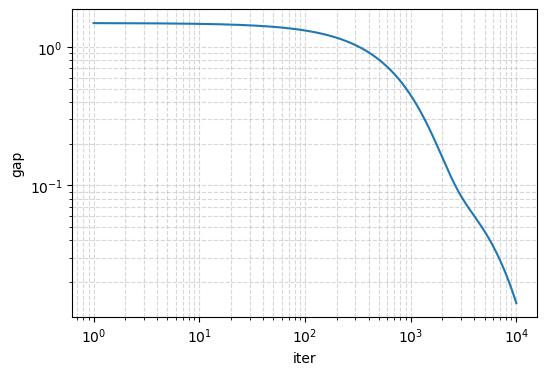

In [102]:
# Centralized solution using the SAME x_selected (Nyström centers)
M = Cov2(x[:n], x_selected)
A = (sigema**2) * Cov(x_selected) + M.T @ M + np.eye(m)
b = M.T @ y[:n]
alpha_star = alpha

mean_alpha_arr = np.array(mean_alpha)   # shape: (T, m)

# Gap to centralized optimum
gap = np.linalg.norm(mean_alpha_arr - alpha_star, axis=1)

# log-log plot
eps = 1e-12
iters = np.arange(1, len(gap) + 1)
plt.figure(figsize=(6,4))
plt.loglog(iters, np.maximum(gap, eps))
plt.xlabel('iter')
plt.ylabel('gap')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


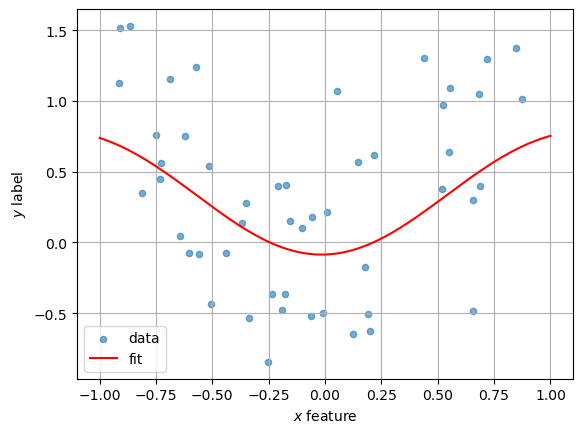

In [107]:
rng = np.random.default_rng(42)
idx = rng.choice(len(x), size=50, replace=False)  # 抽 50 个点
plt.scatter(np.array(x)[idx], np.array(y)[idx], s=20, alpha=0.6, label='data')

# 画预测曲线
xo = np.linspace(-1, 1, 250)
yo = Cov2(xo, x_selected) @ mean_alpha_arr[iter-1]
plt.plot(xo, yo, 'r-', label='fit')

plt.xlabel(r'$x$ feature')
plt.ylabel(r'$y$ label')
plt.grid()
plt.legend()
plt.show()